# Assignment2 – ablation (Rank)
## Ablation Study on LoRA Rank

이 노트북은 `lora_rank` ablation만 실행합니다. (GPU 4 사용)  
실행 전 같은 디렉터리에 `experiment_utils.py` 가 있는지 확인하세요.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "4"

In [2]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-large"
).to(device)
print("BLIP model loaded")

/home/GenAI_202255597/miniconda3/envs/genai-assignment2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


BLIP model loaded


In [4]:
import pandas
from experiment_utils import (
    ABLATION_DATASET,
    BASE_ABLATION_DIR,
    BASE_DATASET_TRAINING_DIR,
    BASE_OUTPUT_DIR,
    DEFAULT_LORA_ALPHA,
    DEFAULT_LORA_RANK,
    DEFAULT_EXPERIMENT_STEPS,
    LORA_RANK_EXPERIMENTS,
    experiment_records,
    run_lora_training_experiment,
    generate_lora_comparison_grid,
)
print("experiment_utils imported")

experiment_utils imported


In [5]:
RUN_ABLATION = True

## 6. Ablation Study on LoRA Rank

대표 데이터셋(`web_crawled`)에서 `lora_rank`만 변경하고  
나머지 설정은 고정하여 비교합니다.

Resolving data files: 100%|██████████| 51/51 [00:00<00:00, 157518.04it/s]


Loaded web_crawled from ./data/web_crawled_custom_dataset; metadata=./data/web_crawled_custom_dataset/train/metadata.csv


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Launching training on one GPU.


Resolving data files: 100%|██████████| 51/51 [00:00<00:00, 204502.39it/s]


Loaded web_crawled from ./data/web_crawled_custom_dataset; metadata=./data/web_crawled_custom_dataset/train/metadata.csv


You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
Detected kernel version 5.4.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


Launching training on one GPU.


Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 17.45it/s]


Comparison order: ['rank=4, alpha=4', 'rank=8, alpha=4', 'rank=16, alpha=4']


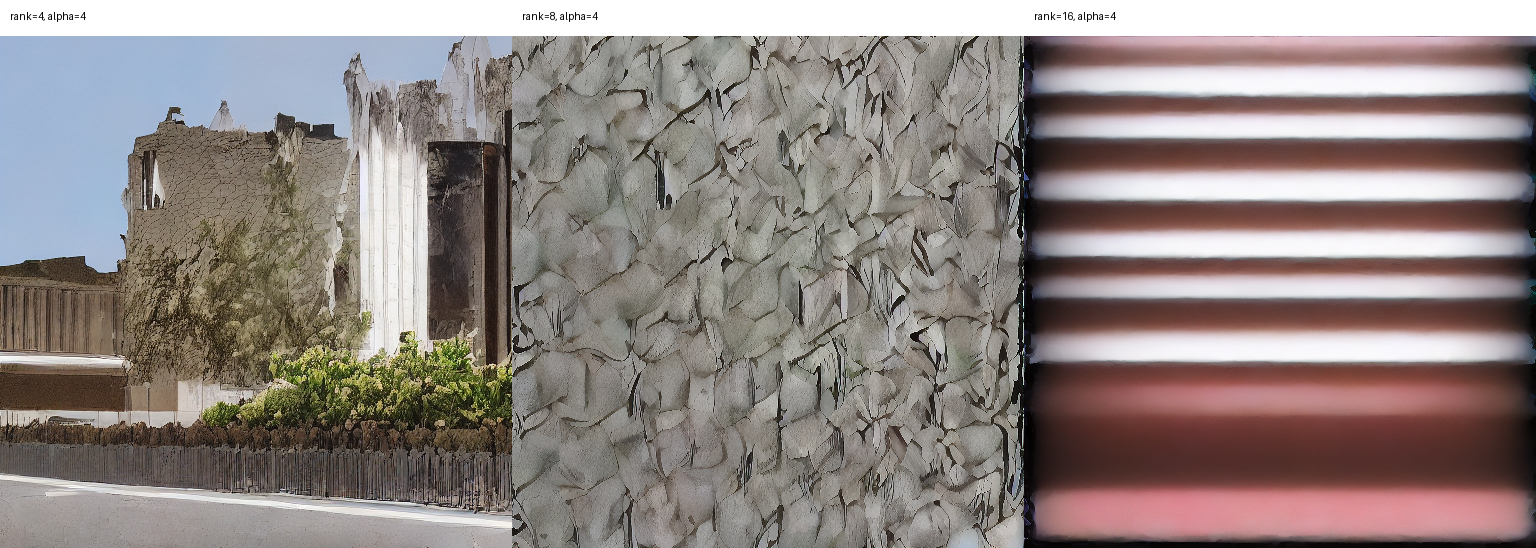

In [6]:
rank_ablation_dirs = []

if RUN_ABLATION:
    for lora_rank in LORA_RANK_EXPERIMENTS:
        lora_dir = run_lora_training_experiment(
            dataset_config=ABLATION_DATASET,
            processor=processor,
            blip_model=blip_model,
            device=device,
            lora_rank=lora_rank,
            lora_alpha=DEFAULT_LORA_ALPHA,
            max_steps=DEFAULT_EXPERIMENT_STEPS,
            experiment_type="rank",
        )
        rank_ablation_dirs.append(lora_dir)

    baseline_lora_dir = os.path.join(
        BASE_DATASET_TRAINING_DIR,
        ABLATION_DATASET["name"],
        f"rank{DEFAULT_LORA_RANK}_alpha{DEFAULT_LORA_ALPHA}",
    )
    rank_dir_by_value = {
        rank: os.path.join(BASE_ABLATION_DIR, "rank", f"rank{rank}_alpha{DEFAULT_LORA_ALPHA}")
        for rank in LORA_RANK_EXPERIMENTS
    }
    rank_dir_by_value[DEFAULT_LORA_RANK] = baseline_lora_dir
    rank_values_for_grid = sorted(rank_dir_by_value)

    rank_result_image = os.path.join(BASE_ABLATION_DIR, "rank_comparison.png")
    rank_grid = generate_lora_comparison_grid(
        prompt=ABLATION_DATASET["prompt"],
        lora_dirs=[rank_dir_by_value[rank] for rank in rank_values_for_grid],
        labels=[f"rank={rank}, alpha={DEFAULT_LORA_ALPHA}" for rank in rank_values_for_grid],
        save_path=rank_result_image,
        device=device,
    )
    display(rank_grid)

    for record in experiment_records:
        if record["experiment_type"] == "rank":
            record["result_image"] = rank_result_image
else:
    print("Set RUN_ABLATION = True to run lora_rank ablation.")

## 7. Experiment Summary (Rank)

학습 설정과 결과 이미지 경로를 CSV로 저장합니다.

In [7]:
summary_path = os.path.join(BASE_OUTPUT_DIR, "experiment_summary_rank.csv")
summary_df = pandas.DataFrame(experiment_records)
summary_df.to_csv(summary_path, index=False)
summary_df

,experiment_type,dataset,prompt,lora_rank,lora_alpha,max_train_steps,output_dir,result_image
0,rank,web_crawled,a building,8,4,2000,./lora_experiments/ablation/rank/rank8_alpha4,./lora_experiments/ablation/rank_comparison.png
1,rank,web_crawled,a building,16,4,2000,./lora_experiments/ablation/rank/rank16_alpha4,./lora_experiments/ablation/rank_comparison.png
